# Prédiction du score d'addiction à l'alcool
## Modèles de Machine Learning (comparaison et analyse) 

**Dataset :** Students-mat & student-por  
**Variable cible :** `Dalc` — Nombre de verres d'alcool par jour

Ce notebook applique plusieurs algorithmes de régression pour prédire le score d'addiction à l'alcool des étudiants.

In [117]:
#%pip install scikit-learn
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score)
from sklearn.model_selection import GridSearchCV


from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBRegressor

## Chargement et traitement des données

In [120]:
data_mat = pd.read_csv("BDD_initial/student-mat.csv", sep=",", index_col=0)
data_mat.head()
data_por = pd.read_csv("BDD_initial/student-por.csv", sep=",", index_col=0)
data_por.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
school,,,,,,,,,,,,,,,,,,,,,
GP,F,18,U,GT3,A,4,4,at_home,teacher,course,...,4,3,4,1,1,3,4,0,11,11
GP,F,17,U,GT3,T,1,1,at_home,other,course,...,5,3,3,1,1,3,2,9,11,11
GP,F,15,U,LE3,T,1,1,at_home,other,other,...,4,3,2,2,3,3,6,12,13,12
GP,F,15,U,GT3,T,4,2,health,services,home,...,3,2,2,1,1,5,0,14,14,14
GP,F,16,U,GT3,T,3,3,other,other,home,...,4,3,2,1,2,5,0,11,13,13


In [121]:
y = data_mat["Dalc"]
y
X = data_mat[["G1", "G2", "G3", "freetime", "goout", "health", "absences", "age", "studytime", "Mjob","Fjob", "reason", "activities","romantic"]]

y_por = data_por["Dalc"]
y_por
X_por = data_por[["G1", "G2", "G3", "freetime", "goout", "health", "absences", "age", "studytime", "Mjob","Fjob", "reason", "activities","romantic"]]


In [122]:
categorical_cols = data_mat.drop(["Dalc","Walc"],axis=1).columns
data_mat1 = data_mat.drop(["Dalc","Walc"],axis=1)
print(categorical_cols)

categorical_cols_por = data_por.drop(["Dalc","Walc"],axis=1).columns
data_por1 = data_por.drop(["Dalc","Walc"],axis=1)
categorical_cols_por

Index(['sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob',
       'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures',
       'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher',
       'internet', 'romantic', 'famrel', 'freetime', 'goout', 'health',
       'absences', 'G1', 'G2', 'G3'],
      dtype='str')


Index(['sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob',
       'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures',
       'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher',
       'internet', 'romantic', 'famrel', 'freetime', 'goout', 'health',
       'absences', 'G1', 'G2', 'G3'],
      dtype='str')

In [103]:
print(data_mat1.dtypes)
data_mat1.describe()
print(data_por1.dtypes)
print(data_por1.isnull().sum())
data_por1.describe()

sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [123]:
data_mat2 = data_mat1.copy()

#variables à transformer de texte en nombre

categorical_cols = data_mat2.select_dtypes(include='object').columns
print(f"Variables catégorielles à encoder : {list(categorical_cols)}")

data_por2 = data_por1.copy()

#variables à transformer de texte en nombre

categorical_cols = data_por2.select_dtypes(include='object').columns
print(f"Variables catégorielles à encoder : {list(categorical_cols)}")

Variables catégorielles à encoder : ['sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Variables catégorielles à encoder : ['sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


C:\Users\sidsm\AppData\Local\Temp\ipykernel_6400\1002293151.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data_mat2.select_dtypes(include='object').columns
C:\Users\sidsm\AppData\Local\Temp\ipykernel_6400\1002293151.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/doc

### Prétraitement des données

OneHotEncoder créé une nouvelle colonne pour chaque catégorie possible. Chaque colonne contient 1 si l'individu appartient à la catégorie, sinon 0. 
Les catégories ne sont plus hiérarchisées mais cela augmente grandement le nombre de colonne. 

L'argument sparse_output=False permet de stocker les données dans un tableau numpy

handle_unknown='ignore' évite les erreurs si une catégorie apparaît dans le test mais pas dans le train

In [127]:
from sklearn.preprocessing import OneHotEncoder

# sparse_output=False permet d'avoir un tableau numpy classique
# handle_unknown='ignore' évite les erreurs si une catégorie apparaît dans le test mais pas dans le train
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

categorical_data = data_mat1[categorical_cols]
encoded_data = encoder.fit_transform(categorical_data)

#On crée un nouveau DataFrame avec les noms de colonnes générés (ex: 'Mjob_teacher', 'Mjob_health', etc.)
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_cols), index=data_mat1.index)

#On fusionne avec les colonnes numériques d'origine
data_mat_final = pd.concat([data_mat1.drop(categorical_cols, axis=1), encoded_df], axis=1)

print("\nAperçu après OneHotEncoding (nombre de colonnes a augmenté) :")
print(f"Ancien nombre de colonnes : {data_mat1.shape[1]}")
print(f"Nouveau nombre de colonnes : {data_mat_final.shape[1]}")
data_mat_final.head()


Aperçu après OneHotEncoding (nombre de colonnes a augmenté) :
Ancien nombre de colonnes : 30
Nouveau nombre de colonnes : 55


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,health,...,activities_no,activities_yes,nursery_no,nursery_yes,higher_no,higher_yes,internet_no,internet_yes,romantic_no,romantic_yes
school,,,,,,,,,,,,,,,,,,,,,
GP,18,4,4,2,2,0,4,3,4,3,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
GP,17,1,1,1,2,0,5,3,3,3,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
GP,15,1,1,1,2,3,4,3,2,3,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
GP,15,4,2,1,3,0,3,2,2,5,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
GP,16,3,3,1,2,0,4,3,2,5,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0


In [128]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data_mat2[col] = le.fit_transform(data_mat2[col])
    label_encoders[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nAperçu après encodage :")
data_mat2.head()

  sex: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
  address: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
  famsize: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
  Pstatus: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
  Mjob: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4)}
  Fjob: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4)}
  reason: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3)}
  guardian: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}
  schoolsup: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
  famsup: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
  paid: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
  activities: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
  nurse

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3
school,,,,,,,,,,,,,,,,,,,,,
GP,0,18,1,0,0,4,4,0,4,0,...,0,0,4,3,4,3,6,5,6,6
GP,0,17,1,0,1,1,1,0,2,0,...,1,0,5,3,3,3,4,5,5,6
GP,0,15,1,1,1,1,1,0,2,2,...,1,0,4,3,2,3,10,7,8,10
GP,0,15,1,0,1,4,2,1,3,1,...,1,1,3,2,2,5,2,15,14,15
GP,0,16,1,0,1,3,3,2,2,1,...,0,0,4,3,2,5,4,6,10,10


In [126]:
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data_por2[col] = le.fit_transform(data_por2[col])
    label_encoders[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nAperçu après encodage :")
data_por2.head()

  sex: {'F': np.int64(0), 'M': np.int64(1)}
  address: {'R': np.int64(0), 'U': np.int64(1)}
  famsize: {'GT3': np.int64(0), 'LE3': np.int64(1)}
  Pstatus: {'A': np.int64(0), 'T': np.int64(1)}
  Mjob: {'at_home': np.int64(0), 'health': np.int64(1), 'other': np.int64(2), 'services': np.int64(3), 'teacher': np.int64(4)}
  Fjob: {'at_home': np.int64(0), 'health': np.int64(1), 'other': np.int64(2), 'services': np.int64(3), 'teacher': np.int64(4)}
  reason: {'course': np.int64(0), 'home': np.int64(1), 'other': np.int64(2), 'reputation': np.int64(3)}
  guardian: {'father': np.int64(0), 'mother': np.int64(1), 'other': np.int64(2)}
  schoolsup: {'no': np.int64(0), 'yes': np.int64(1)}
  famsup: {'no': np.int64(0), 'yes': np.int64(1)}
  paid: {'no': np.int64(0), 'yes': np.int64(1)}
  activities: {'no': np.int64(0), 'yes': np.int64(1)}
  nursery: {'no': np.int64(0), 'yes': np.int64(1)}
  higher: {'no': np.int64(0), 'yes': np.int64(1)}
  internet: {'no': np.int64(0), 'yes': np.int64(1)}
  romantic:

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3
school,,,,,,,,,,,,,,,,,,,,,
GP,0,18,1,0,0,4,4,0,4,0,...,0,0,4,3,4,3,4,0,11,11
GP,0,17,1,0,1,1,1,0,2,0,...,1,0,5,3,3,3,2,9,11,11
GP,0,15,1,1,1,1,1,0,2,2,...,1,0,4,3,2,3,6,12,13,12
GP,0,15,1,0,1,4,2,1,3,1,...,1,1,3,2,2,5,0,14,14,14
GP,0,16,1,0,1,3,3,2,2,1,...,0,0,4,3,2,5,0,11,13,13


Séparation des jeux de données encoder par label encoder et onehotencoder

In [129]:
X_train, X_test, y_train, y_test = train_test_split(data_mat2, y, test_size=0.2, random_state=0)
X_train_por, X_test_por, y_train_por, y_test_por = train_test_split(data_por2, y_por, test_size=0.2, random_state=0)


In [130]:
X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe = train_test_split(data_mat_final, y, test_size=0.2, random_state=0)


In [139]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(data_mat_final)

X_ohe=scaler.transform(data_mat_final) 

scaler.fit(data_mat2)

X=scaler.transform(data_mat2) 

In [150]:
from sklearn.decomposition import PCA

mypca_ohe = PCA(n_components=0.95) 

mypca_ohe.fit_transform(X_ohe)
# Modèle d'ACP

mypca_ohe.fit(X_ohe)

data_sortie_ohe = mypca_ohe.fit_transform(X_ohe)

# Bruit estim
print(mypca_ohe.noise_variance_,"\n")

mypca = PCA(n_components=0.95) 

mypca.fit_transform(X)
# Modèle d'ACP

mypca.fit(X)

data_sortie = mypca.fit_transform(X)

# Bruit estim
print(mypca.noise_variance_,"\n")


0.10727466921355032 

0.25188175330468854 



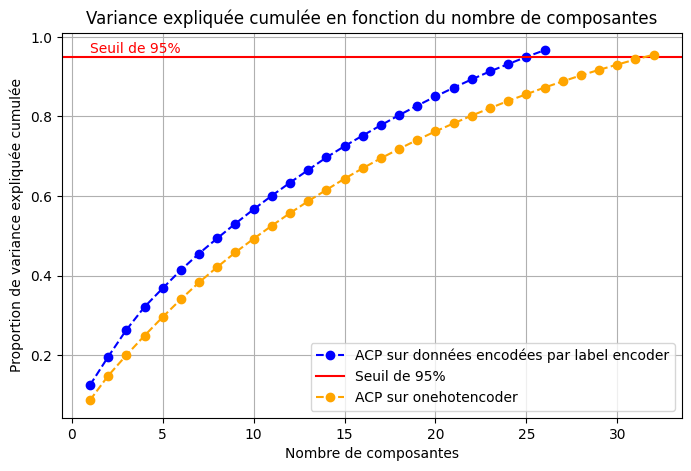

In [145]:


variance_cumulee_ohe = np.cumsum(mypca_ohe.explained_variance_ratio_)
variance_cumulee = np.cumsum(mypca.explained_variance_ratio_)


# 3. On trace le graphique
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(variance_cumulee) + 1), variance_cumulee, marker='o', linestyle='--',color='blue')

# Ajout d'une ligne rouge horizontale au seuil de 95%
plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(1, 0.96, 'Seuil de 95%', color='red')

plt.title("Variance expliquée cumulée en fonction du nombre de composantes")
plt.xlabel("Nombre de composantes")
plt.ylabel("Proportion de variance expliquée cumulée")
plt.grid(True)

plt.plot(range(1, len(variance_cumulee_ohe) + 1), variance_cumulee_ohe, marker='o', linestyle='--', color='orange')
plt.legend(["ACP sur données encodées par label encoder", "Seuil de 95%", "ACP sur onehotencoder"])

plt.show()

In [154]:
X_train_stand, X_test_stand, y_train_stand, y_test_stand = train_test_split(data_sortie, y, test_size=0.2, random_state=0)


In [156]:
X_train_stand_ohe, X_test_stand_ohe, y_train_stand_ohe, y_test_stand_ohe = train_test_split(data_sortie_ohe, y, test_size=0.2, random_state=0)


In [157]:
test = LogisticRegression()
test.fit(X_train, y_train)
test.score(X_test, y_test)

c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.6835443037974683

In [158]:
test = LogisticRegression()
test.fit(X_train_ohe, y_train_ohe)
test.score(X_test_ohe, y_test_ohe)


c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7088607594936709

In [159]:
test = LogisticRegression()
test.fit(X_train_stand, y_train_stand)
test.score(X_test_stand, y_test_stand)

0.7468354430379747

In [160]:
test = RandomForestClassifier(n_estimators=100, max_depth=1)
test.fit(X_train_stand, y_train_stand)
test.score(X_test_stand, y_test_stand)

0.7974683544303798

In [161]:
test = RandomForestClassifier(n_estimators=100, max_depth=1)
test.fit(X_train, y_train)
test.score(X_test, y_test)

0.7974683544303798

In [162]:
test = RandomForestClassifier(n_estimators=100, max_depth=1)
test.fit(X_train_stand_ohe, y_train_stand_ohe)
test.score(X_test_stand_ohe, y_test_stand_ohe)

0.7974683544303798

## 4 Entrainement de différents modèles d'apprentissage

La première méthode consiste à effectuer l'entrainement des données à l'aide de la fonction 'cross_val_score' qui sépare le jeu de donnée en 'cv=5' groupe avant d'entrainer les données sur chacun d'entre eux et tester son score sur le dernier groupe.

In [167]:
clf = DecisionTreeRegressor(random_state=0)
scores = cross_val_score(clf, data_sortie_ohe, y, cv=5)
scores.mean()
print(scores)
print(scores.mean())

[-1.22578155 -2.49515152 -0.70830741 -2.19393557 -0.99770115]
-1.524175437317235


Les modèles de régressions ne sont ici pas performant, particulièrement en comparaison avec les modèles de classifications. 

In [ ]:
clf = DecisionTreeClassifier(max_depth=1, min_samples_split=2,
    random_state=0)
scores = cross_val_score(clf, data_sortie_ohe, y, cv=5)
scores.mean()
print(scores)
print(scores.mean())

clf = RandomForestClassifier(n_estimators=100, max_depth=1,
    min_samples_split=2, random_state=0)
scores = cross_val_score(clf, data_sortie_ohe, y, cv=5)
scores.mean()
print(scores)
print(scores.mean())

clf = ExtraTreesClassifier(n_estimators=100, max_depth=1,
    min_samples_split=2, random_state=1)
scores = cross_val_score(clf, data_sortie_ohe, y, cv=5)
print(scores)
print(scores.mean())

scores.mean() > 0.999

[0.70886076 0.65822785 0.67088608 0.63291139 0.69620253]
0.6734177215189874
[0.70886076 0.69620253 0.69620253 0.69620253 0.69620253]
0.6987341772151899
[0.70886076 0.69620253 0.69620253 0.69620253 0.69620253]
0.6987341772151899


np.False_

In [171]:
def nbr_estimator_model(model,n_estim=100):
    best = 0
    best_k=0
    for k in range (1,n_estim,1):
        model_train = model(n_estimators=k)
        model_train.fit(X_train_stand_ohe, y_train_stand_ohe)
        score = model_train.score(X_test_stand_ohe, y_test_stand_ohe)
        if(best<score):
            best=score
            best_k=k
    print("best : ",best_k,best)
    return [best_k,best]

In [172]:
nbr_estimator_model(AdaBoostClassifier)

best :  1 0.7974683544303798


[1, 0.7974683544303798]

In [174]:
modeles = {
    "decision_tree_regressor": DecisionTreeRegressor(),
    "XGBRegressor":XGBRegressor(n_estimators=100,random_state=42),
    "decision_tree_classifier": DecisionTreeClassifier(),
    "random_forest_classifier": RandomForestClassifier(n_estimators=10, max_depth=3),
    "logistic_regression": LogisticRegression(max_iter=1000),
    "gaussian_nb": GaussianNB(),
    "sgd_classifier": SGDClassifier(random_state=1),
    "knn_classifier": KNeighborsClassifier(n_neighbors=5),
    "bagging_classifier": BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=10)

}

Best=None
score_Best=0
list_model_voting = []
for nom, model in modeles.items():
    model.fit(X_train_stand_ohe, y_train_stand_ohe)
    score_model = model.score(X_test_stand_ohe,y_test_stand_ohe)
    print(f"{nom} : {score_model:.4f}")
    if score_model >score_Best:
        Best=model
        score_Best=score_model
    if(score_model >0.5):
        list_model_voting.append((nom, model))
        
model_0 = VotingClassifier(list_model_voting,
                          voting='hard')
model_0.fit(X_train_stand_ohe, y_train_stand_ohe)
model_0.score(X_test_stand_ohe, y_test_stand_ohe)

model_stack = StackingClassifier(list_model_voting,
                             final_estimator=model_0)
model_stack.fit(X_train_stand_ohe, y_train)
model_stack.score(X_test_stand_ohe, y_test_stand_ohe)

if(score_Best>model_0.score(X_test_stand_ohe, y_test_stand_ohe)):
    best=model_0
if(score_Best>model_stack.score(X_test_stand_ohe, y_test_stand_ohe)):
    best=model_stack
print(f"\n\nMeilleur modèle : {best.__class__.__name__} avec un score de {score_Best:.4f}\n\n")

decision_tree_regressor : -1.8187
XGBRegressor : -0.5884
decision_tree_classifier : 0.5949
random_forest_classifier : 0.7975
logistic_regression : 0.6962
gaussian_nb : 0.6962
sgd_classifier : 0.7089
knn_classifier : 0.7468
bagging_classifier : 0.7848


Meilleur modèle : VotingClassifier avec un score de 0.7975




c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [180]:
# Métriques

y_pred_base = Best.predict(X_test_stand_ohe)

mae  = mean_absolute_error(y_test_stand_ohe, y_pred_base)
rmse = np.sqrt(mean_squared_error(y_test_stand_ohe, y_pred_base))
r2   = r2_score(y_test_stand_ohe, y_pred_base)

print("=== Résultats — Modèle de Base ===")
print(f"  MAE  (erreur absolue moyenne) : {mae:.3f}")
print(f"  RMSE (racine erreur quadr.)   : {rmse:.3f}")
print(f"  R²   (coefficient de détermination) : {r2:.3f}")
print(f"\n Le modèle explique {r2*100:.1f}% de la variance du score")


=== Résultats — Modèle de Base ===
  MAE  (erreur absolue moyenne) : 0.329
  RMSE (racine erreur quadr.)   : 0.871
  R²   (coefficient de détermination) : -0.166

 Le modèle explique -16.6% de la variance du score


In [181]:
# Validation croisée (5-fold)
cv_scores = cross_val_score(Best, data_sortie_ohe, y, cv=5, scoring='r2')

print("=== Validation Croisée (5-fold) ===")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: R² = {score:.4f}")
print(f"\n  R^2 moyen  : {cv_scores.mean():.4f}")
print(f"  Écart-type : {cv_scores.std():.4f}")


=== Validation Croisée (5-fold) ===
  Fold 1: R² = -0.2964
  Fold 2: R² = -0.2928
  Fold 3: R² = -0.2776
  Fold 4: R² = -0.2016
  Fold 5: R² = -0.2928

  R^2 moyen  : -0.2723
  Écart-type : 0.0359


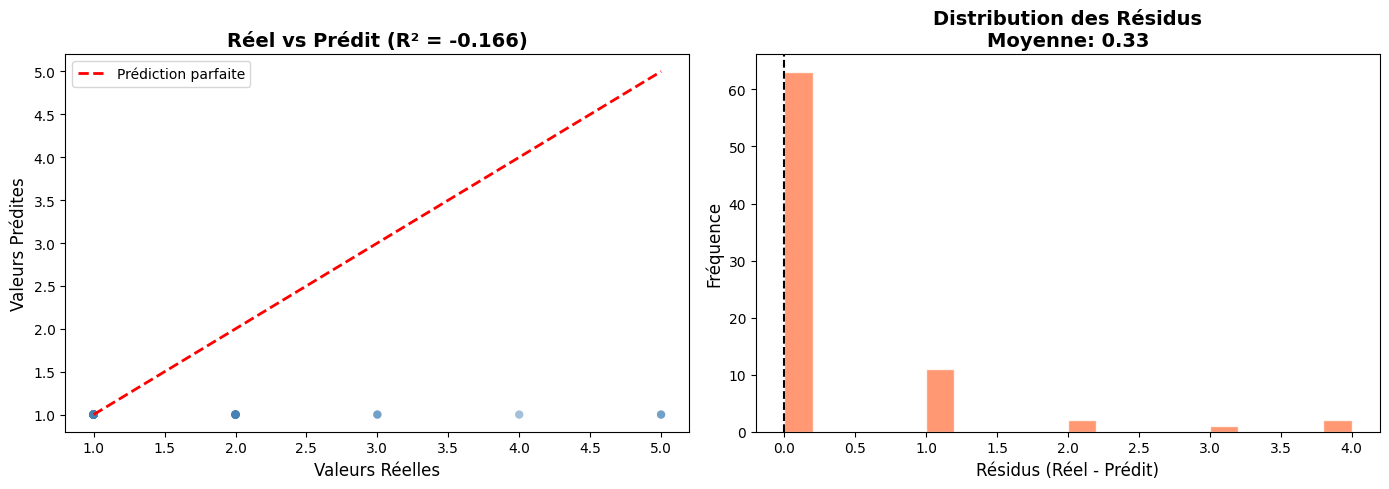

In [182]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prédictions vs Valeurs Réelles
axes[0].scatter(y_test_stand_ohe, y_pred_base, alpha=0.5, color='steelblue', edgecolors='none')
axes[0].plot([y_test_stand_ohe.min(), y_test_stand_ohe.max()], [y_test_stand_ohe.min(), y_test_stand_ohe.max()],
             'r--', lw=2, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs Réelles', fontsize=12)
axes[0].set_ylabel('Valeurs Prédites', fontsize=12)
axes[0].set_title(f'Réel vs Prédit (R² = {r2:.3f})', fontsize=14, fontweight='bold')
axes[0].legend()

# Distribution des Résidus
residuals = y_test_stand_ohe - y_pred_base
axes[1].hist(residuals, bins=20, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Résidus (Réel - Prédit)', fontsize=12)
axes[1].set_ylabel('Fréquence', fontsize=12)
axes[1].set_title(f'Distribution des Résidus\nMoyenne: {residuals.mean():.2f}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()